# HP Meta-Model Offline Evaluation

This notebook runs **offline evaluation** of the trained HP meta-model:
- For each dataset, use the ensemble to recommend an HP config
- In the DB, find the evaluated config **closest** to the recommendation and use its true `primary_score` as "recommended score"
- Compare to default and best to get metrics and plots

**Recommendation mode**: When `USE_FUSED_MAX=True` (default), use **Fused-max**: compute both Archetype-only and Ensemble scores and take the **maximum** per dataset (from `compare_recommendation_methods.ipynb`). The results table includes `recommendation_source` (archetype / ensemble).

**Prerequisite**: Run `train_hp_meta_model.py` to produce `hp_meta_model/`; use `hp_tuning_db_refined.csv` (with refinement columns).

**Avoiding data leakage**: If the model was trained with `--holdout-ratio 0.2` (or `holdout_ratio` in the train notebook), `hp_meta_model/holdout_datasets.json` is written. This evaluation then runs **only on those held-out datasets**, so metrics are a fair out-of-sample estimate. If the file is missing, we fall back to in-sample evaluation and show a warning (results may be optimistic).

---

**Train / clustering alignment**

- **Train**: This evaluation only **reads** outputs under `MODEL_DIR` (e.g. `hp_manifest.json`, per-task ensembles, `hp_archetypes.pkl`). Archetype assignment uses the saved `kmeans_model` + `scaler` + `hp_cols_used`, consistent with `train_hp_meta_model.compute_archetypes` (log1p, scaling), so **train → evaluate** is aligned.
- **compare_archetype_clustering**: That notebook does not write any files read by this evaluation or training; it only suggests "best clustering algorithm/params". To adopt it, change `compute_archetypes` in `train_hp_meta_model.py`, retrain, then run this evaluation again; if using a non-KMeans model, update `assign_config_to_archetype` accordingly (e.g. GMM.predict).

## 1. Config paths and sample size

In [1]:
# Edit paths as needed
HP_DB_PATH = "hp_tuning_db_refined.csv"   # HP tuning DB (with refinement columns)
MODEL_DIR = "hp_meta_model"              # Trained model directory
MAX_DATASETS = 100                        # When not using hold-out: max datasets to evaluate; 0 = all (slower)
SEED = 42
# From compare_recommendation_methods: Fused-max has best mean score. True = take max of Archetype-only and Ensemble score per dataset
USE_FUSED_MAX = True
# When True and holdout_datasets.json exists: evaluate only on hold-out datasets (no leakage). When False or no file: use all/sampled datasets (in-sample).
EVAL_ON_HOLDOUT_ONLY = True

## 2. Dependencies and helper functions

In [2]:
import os
import numpy as np
import pandas as pd

# HP space bounds (same as HPCollector, for normalized distance)
HP_BOUNDS = {
    "hp_num_leaves": (4, 256),
    "hp_max_depth": (3, 15),
    "hp_learning_rate": (0.005, 0.3),
    "hp_n_estimators": (50, 3000),
    "hp_min_child_samples": (5, 100),
    "hp_subsample": (0.5, 1.0),
    "hp_colsample_bytree": (0.3, 1.0),
    "hp_reg_alpha": (1e-8, 10.0),
    "hp_reg_lambda": (1e-8, 10.0),
    "hp_max_bin": (63, 511),
}


def config_to_hp_vector(config, keys):
    """Convert ensemble config (no hp_ prefix) to normalized vector."""
    vec = []
    for k in keys:
        param = k.replace("hp_", "")
        val = config.get(param)
        if val is None:
            return None
        low, high = HP_BOUNDS[k]
        if param in ["learning_rate", "n_estimators", "reg_alpha", "reg_lambda"]:
            val = np.clip(val, low, high)
            log_low, log_high = np.log1p(low), np.log1p(high)
            n = (np.log1p(val) - log_low) / (log_high - log_low)
        else:
            n = (np.clip(val, low, high) - low) / (high - low) if high > low else 0.0
        vec.append(n)
    return np.array(vec, dtype=float)


def row_to_hp_vector(row, keys):
    """Convert a DB row (hp_* cols) to normalized vector."""
    vec = []
    for k in keys:
        val = row.get(k)
        if pd.isna(val):
            return None
        low, high = HP_BOUNDS[k]
        if k in ["hp_learning_rate", "hp_n_estimators", "hp_reg_alpha", "hp_reg_lambda"]:
            val = np.clip(float(val), low, high)
            log_low, log_high = np.log1p(low), np.log1p(high)
            n = (np.log1p(val) - log_low) / (log_high - log_low)
        else:
            val = np.clip(float(val), low, high)
            n = (val - low) / (high - low) if high > low else 0.0
        vec.append(n)
    return np.array(vec, dtype=float)


def hp_distance(v1, v2):
    return np.sqrt(np.sum((v1 - v2) ** 2))


def assign_config_to_archetype(config, archetype_data):
    """Assign recommended config to nearest archetype from training; archetype_data from hp_archetypes.pkl."""
    if archetype_data is None:
        return None
    scaler = archetype_data.get("scaler")
    hp_cols = archetype_data.get("hp_cols_used", [])
    if not hp_cols or scaler is None:
        return None
    vec = []
    for col in hp_cols:
        param = col.replace("hp_", "")
        val = config.get(param)
        if val is None:
            val = 0.0
        val = float(val)
        if param in ["learning_rate", "n_estimators", "reg_alpha", "reg_lambda"]:
            val = np.log1p(np.clip(val, 1e-10, None))
        vec.append(val)
    X = np.array([vec], dtype=float)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    try:
        X_scaled = scaler.transform(X)
    except Exception:
        return "Unknown"
    if "X_scaled_train" in archetype_data and "train_labels" in archetype_data:
        X_train = archetype_data["X_scaled_train"]
        labels = archetype_data["train_labels"]
        dists = np.sqrt(np.sum((X_train - X_scaled) ** 2, axis=1))
        lab = int(labels[np.argmin(dists)])
    elif "kmeans_model" in archetype_data:
        lab = archetype_data["kmeans_model"].predict(X_scaled)[0]
    else:
        return None
    cluster_id_to_name = {info["cluster_id"]: name for name, info in archetype_data.get("archetypes", {}).items()}
    return cluster_id_to_name.get(lab, "Unknown")

def row_to_config(row, keys):
    """Convert DB row (hp_* cols) to config dict (no hp_ prefix) for archetype assignment."""
    config = {}
    for k in keys:
        param = k.replace("hp_", "")
        val = row.get(k)
        if pd.isna(val):
            return None
        if param in ["num_leaves", "max_depth", "n_estimators", "min_child_samples", "max_bin"]:
            config[param] = int(round(float(val)))
        else:
            config[param] = float(val)
    return config

def get_archetype_params_as_config(archetype_data, archetype_name):
    """Get archetype's general parameters as config dict."""
    if not archetype_data or archetype_name is None:
        return None
    info = archetype_data.get("archetypes", {}).get(archetype_name)
    return info.get("params") if info else None

def find_nearest_score_and_rank(rec_config, grp, hp_keys):
    """Find nearest neighbor of recommended config in grp; return (primary_score, rank) or (None, None)."""
    rec_vec = config_to_hp_vector(rec_config, hp_keys)
    if rec_vec is None:
        return None, None
    min_dist = np.inf
    chosen_primary = None
    chosen_idx = None
    for idx, (_, r) in enumerate(grp.iterrows()):
        rvec = row_to_hp_vector(r, hp_keys)
        if rvec is None:
            continue
        d = hp_distance(rec_vec, rvec)
        if d < min_dist:
            min_dist = d
            chosen_primary = float(r["primary_score"])
            chosen_idx = idx
    if chosen_primary is None:
        return None, None
    rank_series = grp["primary_score"].rank(ascending=False, method="min").astype(int)
    chosen_rank = int(rank_series.iloc[chosen_idx]) if chosen_idx is not None else None
    return chosen_primary, chosen_rank

print("Helper functions defined.")

Helper functions defined.


## 3. Load HP DB and trained Ensemble

In [3]:
import json
from train_hp_meta_model import HPEnsemblePredictor, HP_PARAM_NAMES

try:
    from train_hp_meta_model import DATASET_FEATURES
except ImportError:
    DATASET_FEATURES = [
        "n_rows", "n_cols", "n_numeric_cols", "n_cat_cols",
        "cat_ratio", "missing_ratio", "row_col_ratio",
        "class_imbalance_ratio", "n_classes",
        "target_std", "target_skew", "target_kurtosis", "target_nunique_ratio",
        "landmarking_score", "landmarking_score_norm",
        "avg_feature_corr", "max_feature_corr", "avg_target_corr", "max_target_corr",
        "avg_numeric_sparsity", "linearity_gap",
        "corr_graph_components", "corr_graph_clustering", "corr_graph_density",
        "matrix_rank_ratio",
        "std_feature_importance", "max_minus_min_importance",
        "pct_features_above_median_importance", "avg_skewness", "avg_kurtosis",
    ]

df = pd.read_csv(HP_DB_PATH)
print(f"HP DB: {len(df)} rows, {df['dataset_name'].nunique()} datasets")

# Align with train_hp_meta_model: load per-task models from manifest when using per-task training
ensemble = None
ensembles = {}
manifest_path = os.path.join(MODEL_DIR, "hp_manifest.json")
if os.path.exists(manifest_path):
    with open(manifest_path, "r") as f:
        manifest = json.load(f)
    if manifest.get("per_task") and manifest.get("task_types"):
        for tt in manifest["task_types"]:
            subdir = os.path.join(MODEL_DIR, tt)
            if os.path.isdir(subdir) and os.path.isfile(os.path.join(subdir, "hp_scorer.pkl")):
                ensembles[tt] = HPEnsemblePredictor.load(MODEL_DIR, task_type=tt)
        print(f"Loaded per-task: {list(ensembles.keys())}")
if not ensembles:
    ensemble = HPEnsemblePredictor.load(MODEL_DIR)
    print("Single model loaded")

preparator = ensemble.preparator if ensemble is not None else list(ensembles.values())[0].preparator
hp_keys = [c for c in HP_PARAM_NAMES if c in HP_BOUNDS]
print(f"Ensemble ready, HP dim: {len(hp_keys)}")

# Load archetypes per task (same 6 clusters as in training, for assignment and display)
import pickle
archetypes_by_task = {}
if ensembles:
    for tt in ensembles:
        pkl_path = os.path.join(MODEL_DIR, tt, "hp_archetypes.pkl")
        if os.path.isfile(pkl_path):
            with open(pkl_path, "rb") as f:
                archetypes_by_task[tt] = pickle.load(f)
else:
    pkl_path = os.path.join(MODEL_DIR, "hp_archetypes.pkl")
    if os.path.isfile(pkl_path):
        with open(pkl_path, "rb") as f:
            archetypes_by_task["all"] = pickle.load(f)
if archetypes_by_task:
    print(f"Archetypes loaded: {list(archetypes_by_task.keys())}")

HP DB: 135295 rows, 1749 datasets
Loaded per-task: ['classification', 'regression']
Ensemble ready, HP dim: 10
Archetypes loaded: ['classification', 'regression']


## 4. Per-dataset evaluation (recommend → find nearest config → record scores)

When `holdout_datasets.json` exists and `EVAL_ON_HOLDOUT_ONLY=True`, evaluation runs **only on held-out datasets** (excluded during training), so metrics are a fair out-of-sample estimate and avoid data leakage.

In [4]:
# Avoid data leakage: evaluate only on hold-out datasets when the model was trained with hold-out
holdout_path = os.path.join(MODEL_DIR, "holdout_datasets.json")
datasets = None
if EVAL_ON_HOLDOUT_ONLY and os.path.isfile(holdout_path):
    with open(holdout_path, "r") as f:
        holdout_meta = json.load(f)
    holdout_list = holdout_meta.get("holdout_datasets", [])
    all_in_db = set(df["dataset_name"].unique())
    datasets = [d for d in holdout_list if d in all_in_db]
    if datasets:
        print(f"Hold-out evaluation (no leakage): {len(datasets)} datasets from {holdout_path}")
    else:
        print("Hold-out list found but no names in HP DB; falling back to in-sample.")
        datasets = None
if datasets is None:
    dataset_rows = df.drop_duplicates(subset="dataset_name", keep="first")
    datasets = dataset_rows["dataset_name"].tolist()
    if MAX_DATASETS > 0:
        rng = np.random.RandomState(SEED)
        idx = rng.permutation(len(datasets))[:MAX_DATASETS]
        datasets = [datasets[i] for i in idx]
    if not os.path.isfile(holdout_path):
        print("WARNING: No holdout_datasets.json found. Evaluating on training data (in-sample); results may be optimistic.")
    else:
        print("EVAL_ON_HOLDOUT_ONLY is False or no hold-out datasets in DB; using full/sampled list.")
print(f"Will evaluate {len(datasets)} datasets...")

results = []
for i, dname in enumerate(datasets):
    if (i + 1) % 50 == 0 or i == 0:
        print(f"  {i+1}/{len(datasets)} {dname[:50]}...")
    grp = df[df["dataset_name"] == dname]
    if grp.empty:
        continue
    row0 = grp.iloc[0]
    task_type = str(row0.get("task_type", "classification")).strip().lower()
    if task_type not in ("classification", "regression"):
        task_type = "classification"

    # Align with training: use ensemble and preparator for this task type
    if ensembles:
        ensemble_cur = ensembles.get(task_type)
        if ensemble_cur is None:
            continue
        preparator_cur = ensemble_cur.preparator
    else:
        ensemble_cur = ensemble
        preparator_cur = preparator

    arch_data = archetypes_by_task.get("all") if "all" in archetypes_by_task else archetypes_by_task.get(task_type)

    meta_row = row0.to_dict()
    try:
        tt_enc = preparator_cur.task_type_encoder.transform([task_type])[0]
    except Exception:
        tt_enc = 0
    meta_row["task_type_encoded"] = tt_enc
    ref = preparator_cur.encode_refinement_dimensions(task_type, meta_row)
    for k, v in ref.items():
        meta_row[k] = v
    pred_df = pd.DataFrame([meta_row])
    if len([c for c in preparator_cur.feature_columns_predictor if c in pred_df.columns]) < len(preparator_cur.feature_columns_predictor):
        pred_df = pred_df.reindex(columns=preparator_cur.feature_columns_predictor)
        pred_df = pred_df.fillna(preparator_cur.fill_values)

    try:
        out = ensemble_cur.predict(pred_df, task_type=task_type, n_perturbations=20, seed=SEED)
    except Exception as e:
        continue
    rec_config = out["best_config"]
    rec_vec = config_to_hp_vector(rec_config, hp_keys)
    if rec_vec is None:
        continue

    arch_data = archetypes_by_task.get("all") if "all" in archetypes_by_task else archetypes_by_task.get(task_type)
    archetype_name = assign_config_to_archetype(rec_config, arch_data) if arch_data else None

    primary_scores = grp["primary_score"].values
    best_score = float(np.nanmax(primary_scores))
    worst_score = float(np.nanmin(primary_scores))
    default_row = grp[(grp.get("hp_is_default", pd.Series(0)) == 1)]
    if default_row.empty:
        default_row = grp[grp.get("hp_config_name", pd.Series("")) == "default"]
    default_score = float(default_row["primary_score"].iloc[0]) if len(default_row) > 0 else primary_scores[0]

    score_arch, rank_arch, arch_name_arch = None, None, None
    if arch_data:
        def_row = default_row.iloc[0] if len(default_row) > 0 else grp.iloc[0]
        default_config = row_to_config(def_row.to_dict(), hp_keys)
        if default_config:
            arch_name_arch = assign_config_to_archetype(default_config, arch_data)
            rec_arch = get_archetype_params_as_config(arch_data, arch_name_arch)
            if rec_arch:
                score_arch, rank_arch = find_nearest_score_and_rank(rec_arch, grp, hp_keys)

    min_dist = np.inf
    chosen_primary = None
    chosen_idx = None
    for idx, (_, r) in enumerate(grp.iterrows()):
        rvec = row_to_hp_vector(r, hp_keys)
        if rvec is None:
            continue
        d = hp_distance(rec_vec, rvec)
        if d < min_dist:
            min_dist = d
            chosen_primary = float(r["primary_score"])
            chosen_idx = idx
    if chosen_primary is None:
        continue

    rank_series = grp["primary_score"].rank(ascending=False, method="min").astype(int)
    chosen_rank = int(rank_series.iloc[chosen_idx]) if chosen_idx is not None else np.nan
    if USE_FUSED_MAX and score_arch is not None and score_arch >= chosen_primary:
        recommended_score, rank, archetype_name = score_arch, rank_arch, arch_name_arch
        recommendation_source = "archetype"
    else:
        recommended_score, rank = chosen_primary, chosen_rank
        archetype_name = assign_config_to_archetype(rec_config, arch_data) if arch_data else None
        recommendation_source = "ensemble"
    score_range = best_score - worst_score
    regret = (best_score - recommended_score) / score_range if score_range and not np.isnan(score_range) else 0
    results.append({
        "dataset": dname,
        "task_type": task_type,
        "archetype": archetype_name,
        "recommendation_source": recommendation_source,
        "recommended_score": recommended_score,
        "default_score": default_score,
        "best_score": best_score,
        "beat_default": recommended_score >= default_score,
        "rank": rank,
        "regret": regret,
    })

res_df = pd.DataFrame(results)
print(f"\nDone, valid results: {len(res_df)} datasets.")

Will evaluate 100 datasets...
  1/100 FOREX_euraud-day-High...


  50/100 FOREX_eursek-day-High...
  100/100 Long...

Done, valid results: 100 datasets.


## 4.5 Testset performance

Run the same evaluation (as in Section 4) on datasets listed under the **testset** directory to see performance on the held-out test set. Filenames in testset (e.g. `splice.csv`) match `dataset_name` in the HP DB by stem or exact name.

In [5]:
TESTSET_DIR = "testset"

# Get dataset name list from testset dir (filename stems match DB dataset_name)
if not os.path.isdir(TESTSET_DIR):
    print(f"Directory {TESTSET_DIR} not found; create it and add test files (e.g. splice.csv).")
    res_df_test = pd.DataFrame()
else:
    stems = []
    for f in os.listdir(TESTSET_DIR):
        base, ext = os.path.splitext(f)
        if ext.lower() == ".csv" or not ext:
            stems.append(base)
    stems = list(dict.fromkeys(stems))
    # Each testset file (stem) maps to 1 dataset: first matching dataset_name in DB
    db_names = df["dataset_name"].astype(str).unique()
    testset_datasets = []
    for s in stems:
        for d in db_names:
            if d == s or d.startswith(s + "_") or d.startswith(s + "-"):
                testset_datasets.append(d)
                break
    if not testset_datasets:
        print(f"Stems in testset: {stems}")
        print("No matching dataset_name in HP DB; check testset filenames vs dataset_name.")
        res_df_test = pd.DataFrame()
    else:
        print(f"Testset matched {len(testset_datasets)} datasets (stems: {stems})")
        results_test = []
        for i, dname in enumerate(testset_datasets):
            if (i + 1) % 20 == 0 or i == 0:
                print(f"  {i+1}/{len(testset_datasets)} {dname[:50]}...")
            grp = df[df["dataset_name"] == dname]
            if grp.empty:
                continue
            row0 = grp.iloc[0]
            task_type = str(row0.get("task_type", "classification")).strip().lower()
            if task_type not in ("classification", "regression"):
                task_type = "classification"

            if ensembles:
                ensemble_cur = ensembles.get(task_type)
                if ensemble_cur is None:
                    continue
                preparator_cur = ensemble_cur.preparator
            else:
                ensemble_cur = ensemble
                preparator_cur = preparator

            arch_data = archetypes_by_task.get("all") if "all" in archetypes_by_task else archetypes_by_task.get(task_type)

            meta_row = row0.to_dict()
            try:
                tt_enc = preparator_cur.task_type_encoder.transform([task_type])[0]
            except Exception:
                tt_enc = 0
            meta_row["task_type_encoded"] = tt_enc
            ref = preparator_cur.encode_refinement_dimensions(task_type, meta_row)
            for k, v in ref.items():
                meta_row[k] = v
            pred_df = pd.DataFrame([meta_row])
            if len([c for c in preparator_cur.feature_columns_predictor if c in pred_df.columns]) < len(preparator_cur.feature_columns_predictor):
                pred_df = pred_df.reindex(columns=preparator_cur.feature_columns_predictor)
                pred_df = pred_df.fillna(preparator_cur.fill_values)

            try:
                out = ensemble_cur.predict(pred_df, task_type=task_type, n_perturbations=20, seed=SEED)
            except Exception:
                continue
            rec_config = out["best_config"]
            rec_vec = config_to_hp_vector(rec_config, hp_keys)
            if rec_vec is None:
                continue

            primary_scores = grp["primary_score"].values
            best_score = float(np.nanmax(primary_scores))
            worst_score = float(np.nanmin(primary_scores))
            default_row = grp[(grp.get("hp_is_default", pd.Series(0)) == 1)]
            if default_row.empty:
                default_row = grp[grp.get("hp_config_name", pd.Series("")) == "default"]
            default_score = float(default_row["primary_score"].iloc[0]) if len(default_row) > 0 else primary_scores[0]

            score_arch, rank_arch, arch_name_arch = None, None, None
            if arch_data:
                def_row = default_row.iloc[0] if len(default_row) > 0 else grp.iloc[0]
                default_config = row_to_config(def_row.to_dict(), hp_keys)
                if default_config:
                    arch_name_arch = assign_config_to_archetype(default_config, arch_data)
                    rec_arch = get_archetype_params_as_config(arch_data, arch_name_arch)
                    if rec_arch:
                        score_arch, rank_arch = find_nearest_score_and_rank(rec_arch, grp, hp_keys)

            min_dist = np.inf
            chosen_primary = None
            chosen_idx = None
            for idx, (_, r) in enumerate(grp.iterrows()):
                rvec = row_to_hp_vector(r, hp_keys)
                if rvec is None:
                    continue
                d = hp_distance(rec_vec, rvec)
                if d < min_dist:
                    min_dist = d
                    chosen_primary = float(r["primary_score"])
                    chosen_idx = idx
            if chosen_primary is None:
                continue

            rank_series = grp["primary_score"].rank(ascending=False, method="min").astype(int)
            chosen_rank = int(rank_series.iloc[chosen_idx]) if chosen_idx is not None else np.nan
            if USE_FUSED_MAX and score_arch is not None and score_arch >= chosen_primary:
                recommended_score, rank, archetype_name = score_arch, rank_arch, arch_name_arch
                recommendation_source = "archetype"
            else:
                recommended_score, rank = chosen_primary, chosen_rank
                archetype_name = assign_config_to_archetype(rec_config, arch_data) if arch_data else None
                recommendation_source = "ensemble"
            score_range = best_score - worst_score
            regret = (best_score - recommended_score) / score_range if score_range and not np.isnan(score_range) else 0
            results_test.append({
                "dataset": dname,
                "task_type": task_type,
                "archetype": archetype_name,
                "recommendation_source": recommendation_source,
                "recommended_score": recommended_score,
                "default_score": default_score,
                "best_score": best_score,
                "beat_default": recommended_score >= default_score,
                "rank": rank,
                "regret": regret,
            })

        res_df_test = pd.DataFrame(results_test)
        print(f"\nTestset done, valid results: {len(res_df_test)} datasets.")

        if len(res_df_test) > 0:
            n = len(res_df_test)
            print("\n--- Testset summary ---")
            print(f"  Datasets evaluated: {n}")
            print(f"  Mean primary_score (recommended): {res_df_test['recommended_score'].mean():.6f}")
            print(f"  Mean primary_score (default):     {res_df_test['default_score'].mean():.6f}")
            print(f"  Mean primary_score (best):        {res_df_test['best_score'].mean():.6f}")
            print(f"  % datasets where recommended >= default: {100 * res_df_test['beat_default'].mean():.1f}%")
            print(f"  Median rank of chosen config (1=best):   {res_df_test['rank'].median():.0f}")
            display(res_df_test)

Testset matched 8 datasets (stems: ['hiva_agnostic', 'maternal_health_risk', 'MIC', 'Amazon_employee_access', 'online_shoppers_intention', 'APSFailure', 'E-CommereShippingData', 'splice'])
  1/8 hiva_agnostic...

Testset done, valid results: 8 datasets.

--- Testset summary ---
  Datasets evaluated: 8
  Mean primary_score (recommended): 0.836332
  Mean primary_score (default):     0.826997
  Mean primary_score (best):        0.845913
  % datasets where recommended >= default: 100.0%
  Median rank of chosen config (1=best):   25


,dataset,task_type,archetype,recommendation_source,recommended_score,default_score,best_score,beat_default,rank,regret
0,hiva_agnostic,classification,Unknown,ensemble,0.503955,0.475776,0.541906,True,19,0.410582
1,maternal_health_risk,classification,Large / Wide / High-Capacity,ensemble,0.944972,0.940273,0.951705,True,26,0.086122
2,MIC,classification,Unknown,ensemble,0.863227,0.845492,0.871262,True,17,0.160322
3,Amazon_employee_access_seed_0_nrows_2000_nclas...,classification,Large / Wide / High-Capacity,ensemble,0.720042,0.703764,0.737343,True,39,0.176525
4,online_shoppers_intention,classification,Large,archetype,0.934339,0.934339,0.935276,True,43,0.031861
5,APSFailure_seed_0_nrows_2000_nclasses_10_ncols...,classification,Unknown,ensemble,0.984347,0.980931,0.986958,True,24,0.060715
6,E-CommereShippingData,classification,Large / High-LR / High-Capacity,ensemble,0.744140,0.741004,0.746891,True,32,0.350813
7,splice,classification,Large / Wide / High-Capacity,ensemble,0.995634,0.994400,0.995961,True,24,0.058238


## 5. Summary metrics table

In [6]:
summary = pd.DataFrame({
    "Metric": [
        "Datasets evaluated",
        "Mean primary_score (recommended)",
        "Mean primary_score (default)",
        "Mean primary_score (best)",
        "Mean improvement vs default",
        "% datasets where recommended >= default",
        "Median rank of chosen config (1=best)",
        "Mean normalized regret (0=best)",
    ],
    "Value": [
        len(res_df),
        f"{res_df['recommended_score'].mean():.6f}",
        f"{res_df['default_score'].mean():.6f}",
        f"{res_df['best_score'].mean():.6f}",
        f"{(res_df['recommended_score'] - res_df['default_score']).mean():.6f}",
        f"{100 * res_df['beat_default'].mean():.1f}%",
        f"{res_df['rank'].median():.0f}",
        f"{res_df['regret'].mean():.4f}",
    ],
})
display(summary)

,Metric,Value
0,Datasets evaluated,100
1,Mean primary_score (recommended),0.076701
2,Mean primary_score (default),0.056572
3,Mean primary_score (best),0.091328
4,Mean improvement vs default,0.020129
5,% datasets where recommended >= default,100.0%
6,Median rank of chosen config (1=best),28
7,Mean normalized regret (0=best),0.1263


## 5.5 By-archetype breakdown (6 clusters)

Each archetype is a "typical config" from training clustering: show its **general parameters** (average HPs) and **observed results** in this evaluation (sample count, mean recommended score, % >= default, etc.).

In [7]:
if "archetype" not in res_df.columns or not archetypes_by_task:
    print("Archetypes not loaded or no 'archetype' column in results; run Section 3 and 4 first.")
else:
    task_types_for_arch = list(archetypes_by_task.keys())
    for tt in task_types_for_arch:
        arch_data = archetypes_by_task[tt]
        if not arch_data or "archetypes" not in arch_data:
            continue
        # task_type key in evaluation results (classification/regression for per-task, 'all' for single model)
        res_tt = res_df[res_df["task_type"] == tt] if tt != "all" else res_df
        if res_tt.empty:
            continue
        sub = res_tt.dropna(subset=["archetype"])
        if sub.empty:
            continue
        print(f"\n{'='*60}\nTask type: {tt}\n{'='*60}")
        rows = []
        for arch_name in sub["archetype"].unique():
            mask = sub["archetype"] == arch_name
            grp = sub[mask]
            info = arch_data["archetypes"].get(arch_name, {})
            params = info.get("params", {})
            # general params summary
            gp = ", ".join([f"{k}={v}" for k, v in list(params.items())[:6]])
            if len(params) > 6:
                gp += ", ..."
            rows.append({
                "archetype": arch_name,
                "n": len(grp),
                "mean_rec": grp["recommended_score"].mean(),
                "mean_default": grp["default_score"].mean(),
                "beat_default_%": f"{100 * grp['beat_default'].mean():.1f}%",
                "median_rank": grp["rank"].median(),
                "general_params": gp,
            })
        tab = pd.DataFrame(rows)
        display(tab)
        # Full general parameters per archetype
        print("\nGeneral parameters (full) per archetype:")
        for arch_name in sub["archetype"].unique():
            info = arch_data["archetypes"].get(arch_name, {})
            params = info.get("params", {})
            if params:
                print(f"  [{arch_name}]: {params}")


Task type: classification


,archetype,n,mean_rec,mean_default,beat_default_%,median_rank,general_params
0,Unknown,15,0.727770,0.713630,100.0%,29.0,
1,Large / Wide / High-Capacity,19,0.887186,0.882840,100.0%,29.0,"num_leaves=103, max_depth=12, learning_rate=0...."
2,Large / High-LR / High-Capacity,10,0.701596,0.683716,100.0%,29.0,"num_leaves=142, max_depth=11, learning_rate=0...."
3,Large,39,0.878552,0.878192,100.0%,25.0,"num_leaves=47, max_depth=5, learning_rate=0.08..."



General parameters (full) per archetype:
  [Large / Wide / High-Capacity]: {'num_leaves': 103, 'max_depth': 12, 'learning_rate': np.float64(0.0397), 'n_estimators': 1296, 'min_child_samples': 19, 'subsample': np.float64(0.7573), 'colsample_bytree': np.float64(0.4397), 'reg_alpha': np.float64(0.1034), 'reg_lambda': np.float64(0.1051), 'max_bin': 278}
  [Large / High-LR / High-Capacity]: {'num_leaves': 142, 'max_depth': 11, 'learning_rate': np.float64(0.1294), 'n_estimators': 1043, 'min_child_samples': 36, 'subsample': np.float64(0.7792), 'colsample_bytree': np.float64(0.6271), 'reg_alpha': np.float64(6.4092), 'reg_lambda': np.float64(1.4435), 'max_bin': 406}
  [Large]: {'num_leaves': 47, 'max_depth': 5, 'learning_rate': np.float64(0.0885), 'n_estimators': 1143, 'min_child_samples': 29, 'subsample': np.float64(0.7799), 'colsample_bytree': np.float64(0.7979), 'reg_alpha': np.float64(0.0989), 'reg_lambda': np.float64(0.255), 'max_bin': 207}

Task type: regression


,archetype,n,mean_rec,mean_default,beat_default_%,median_rank,general_params
0,Medium,6,-3.595897,-3.598006,100.0%,39.5,"num_leaves=49, max_depth=5, learning_rate=0.06..."
1,Unknown,9,-3.330077,-3.461250,100.0%,14.0,
2,Large / High-LR / High-Capacity,2,-4.918184,-5.084285,100.0%,11.0,"num_leaves=157, max_depth=12, learning_rate=0...."



General parameters (full) per archetype:
  [Medium]: {'num_leaves': 49, 'max_depth': 5, 'learning_rate': np.float64(0.0687), 'n_estimators': 1202, 'min_child_samples': 14, 'subsample': np.float64(0.7053), 'colsample_bytree': np.float64(0.8385), 'reg_alpha': np.float64(0.0209), 'reg_lambda': np.float64(0.144), 'max_bin': 213}
  [Large / High-LR / High-Capacity]: {'num_leaves': 157, 'max_depth': 12, 'learning_rate': np.float64(0.1332), 'n_estimators': 1052, 'min_child_samples': 18, 'subsample': np.float64(0.7483), 'colsample_bytree': np.float64(0.6926), 'reg_alpha': np.float64(4.3685), 'reg_lambda': np.float64(1.1199), 'max_bin': 341}


## 6. Per-dataset result preview

In [8]:
res_df["improvement_vs_default"] = res_df["recommended_score"] - res_df["default_score"]
res_df.head(20)

,dataset,task_type,archetype,recommendation_source,recommended_score,default_score,best_score,beat_default,rank,regret,improvement_vs_default
0,FOREX_euraud-day-High,classification,Unknown,ensemble,0.693413,0.681992,0.697387,True,11,0.037044,0.011421
1,sylvine_seed_0_nrows_2000_nclasses_10_ncols_10...,classification,Large / Wide / High-Capacity,ensemble,0.977577,0.976110,0.979617,True,15,0.147381,0.001467
2,Acute_Myeloid_Leukemia,regression,Medium,archetype,-0.576343,-0.576343,-0.545504,True,40,0.185216,0.000000
3,analcatdata_authorship,classification,Large / Wide / High-Capacity,ensemble,0.999920,0.999880,0.999970,True,32,0.014937,0.000040
4,"BNG(kr-vs-kp,5000,10)",classification,Large / High-LR / High-Capacity,ensemble,0.992957,0.991660,0.995394,True,50,0.026579,0.001297
5,sulfur,regression,Unknown,ensemble,-0.020329,-0.020639,-0.019861,True,11,0.037807,0.000311
6,Australian_seed_3_nrows_2000_nclasses_10_ncols...,classification,Large / Wide / High-Capacity,ensemble,0.942632,0.939747,0.946553,True,27,0.239351,0.002884
7,mfeat-morphological,classification,Unknown,ensemble,0.999780,0.998125,0.999861,True,18,0.018499,0.001655
8,gina_prior,classification,Large,archetype,0.991197,0.991197,0.991910,True,29,0.026260,0.000000
9,okcupid-stem_seed_4_nrows_2000_nclasses_10_nco...,classification,Large / Wide / High-Capacity,ensemble,0.798487,0.794883,0.805077,True,37,0.278315,0.003604


## 7. Visualization

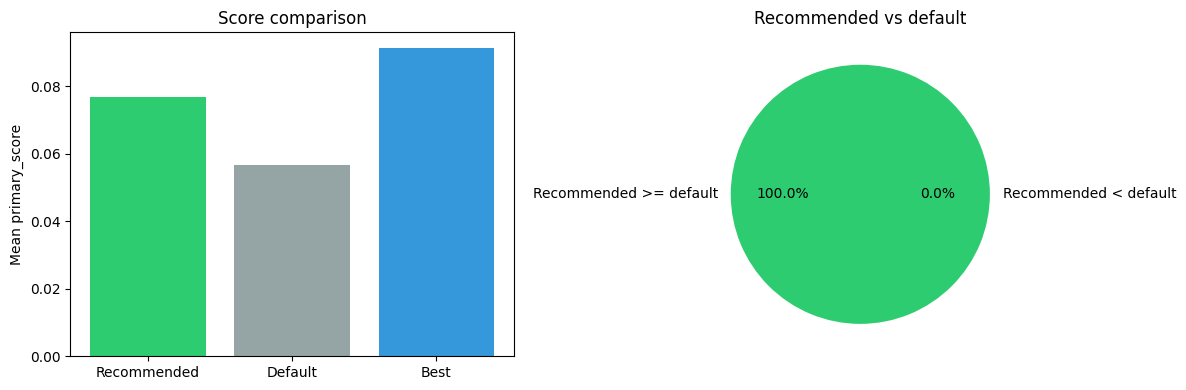

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: mean of three scores
ax = axes[0]
means = [res_df["recommended_score"].mean(), res_df["default_score"].mean(), res_df["best_score"].mean()]
labels = ["Recommended", "Default", "Best"]
colors = ["#2ecc71", "#95a5a6", "#3498db"]
ax.bar(labels, means, color=colors)
ax.set_ylabel("Mean primary_score")
ax.set_title("Score comparison")

# Right: % better than default
ax = axes[1]
beat = res_df["beat_default"].sum()
n = len(res_df)
ax.pie([beat, n - beat], labels=["Recommended >= default", "Recommended < default"], autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"])
ax.set_title("Recommended vs default")

plt.tight_layout()
plt.show()

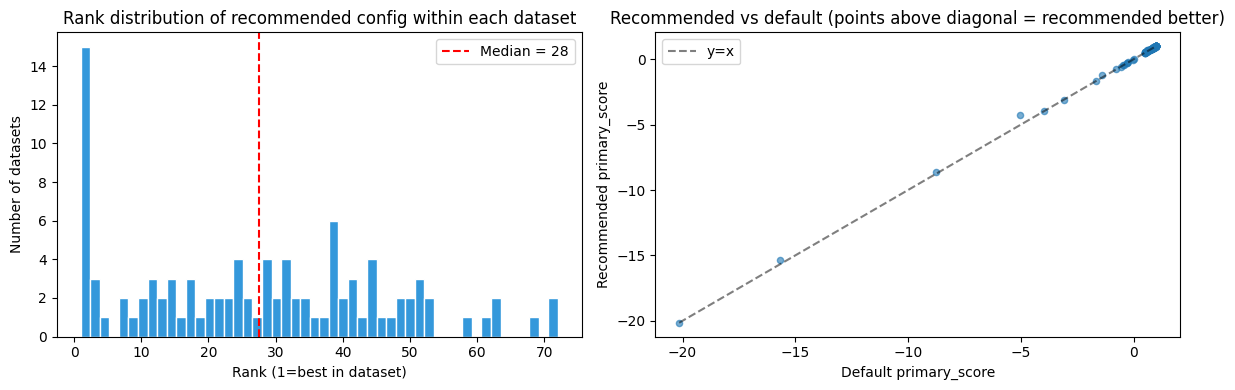

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: rank distribution of chosen config (1=best)
ax = axes[0]
ax.hist(res_df["rank"].dropna(), bins=min(50, int(res_df["rank"].max())), color="#3498db", edgecolor="white")
ax.axvline(res_df["rank"].median(), color="red", linestyle="--", label=f"Median = {res_df['rank'].median():.0f}")
ax.set_xlabel("Rank (1=best in dataset)")
ax.set_ylabel("Number of datasets")
ax.set_title("Rank distribution of recommended config within each dataset")
ax.legend()

# Right: recommended vs default score (above diagonal = recommended better)
ax = axes[1]
ax.scatter(res_df["default_score"], res_df["recommended_score"], alpha=0.6, s=20)
mx = max(res_df["default_score"].max(), res_df["recommended_score"].max())
mn = min(res_df["default_score"].min(), res_df["recommended_score"].min())
ax.plot([mn, mx], [mn, mx], "k--", alpha=0.5, label="y=x")
ax.set_xlabel("Default primary_score")
ax.set_ylabel("Recommended primary_score")
ax.set_title("Recommended vs default (points above diagonal = recommended better)")
ax.legend()

plt.tight_layout()
plt.show()